# Task 3a — Daily Climate Time-Series Forecasting (Delhi)

**Dataset:** *Daily Climate Time Series Data* (Kaggle, *sumanthvrao*) — daily measurements of mean temperature, humidity, wind speed and atmospheric pressure for **Delhi, India**, 2013-01-01 → 2017-04-24 (≈1 575 days).

**Task type:** *Regression* — predict tomorrow's `meantemp` from a sliding window of the last 7 days.

**Goal:** Compare four models — **ANN, SimpleRNN, LSTM, GRU** — on identical inputs.

*Note on metrics:* the rubric asks for ROC-AUC, but ROC-AUC only applies to **classification**.  For this regression task we report **MAE, RMSE and R²** instead, plus a residual histogram and a predicted-vs-actual scatter.  The Seattle Weather notebook (Task 3b) covers ROC-AUC.

## 1. Dataset Understanding

In [1]:
import os, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU       :', tf.config.list_physical_devices('GPU') or 'CPU only')

I0000 00:00:1778756971.794035   18004 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778756971.794492   18004 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778756971.830716   18004 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU       : CPU only


I0000 00:00:1778756972.749870   18004 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778756972.750410   18004 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1778756972.874365   18004 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
DATA_DIR = Path('/home/student/Downloads/archive(1)')
train_raw = pd.read_csv(DATA_DIR / 'DailyDelhiClimateTrain.csv', parse_dates=['date'])
test_raw  = pd.read_csv(DATA_DIR / 'DailyDelhiClimateTest.csv',  parse_dates=['date'])

# Concatenate then re-split chronologically further down
df = pd.concat([train_raw, test_raw], ignore_index=True).sort_values('date').reset_index(drop=True)

print('Date range :', df.date.min().date(), '->', df.date.max().date())
print('Total days :', len(df))
print('Features   :', list(df.columns[1:]))
print('Missing    :', df.isna().sum().sum())
df.head()

Date range : 2013-01-01 -> 2017-04-24
Total days : 1576
Features   : ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
Missing    : 0


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
# Sanity-check: a single day shows pressure = 0 — clearly a sensor glitch.
# Replace impossible pressure values (<900 hPa) with the column median.
bad = df.meanpressure < 900
print('Implausible pressure rows:', bad.sum())
df.loc[bad, 'meanpressure'] = df.meanpressure[~bad].median()
df.describe().round(2)

Implausible pressure rows: 5


,date,meantemp,humidity,wind_speed,meanpressure
count,1576,1576.00,1576.00,1576.00,1576.00
mean,2015-02-27 10:15:50.253807,25.22,60.45,6.90,1013.15
min,2013-01-01 00:00:00,6.00,13.43,0.00,938.07
25%,2014-01-29 18:00:00,18.50,49.75,3.70,1001.97
50%,2015-02-27 12:00:00,27.17,62.44,6.36,1009.12
75%,2016-03-27 06:00:00,31.14,72.12,9.26,1015.20
max,2017-04-24 00:00:00,38.71,100.00,42.22,7679.33
std,NaN,7.35,16.98,4.51,168.65


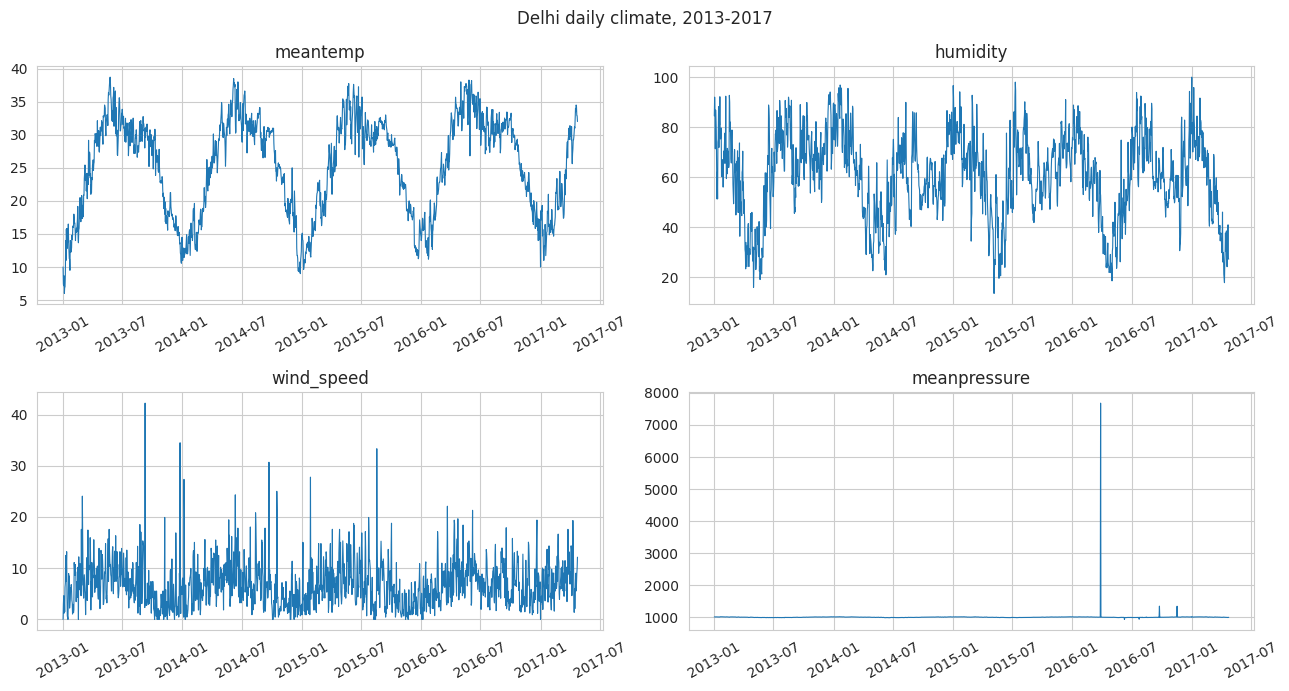

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col in zip(axes.flat, ['meantemp','humidity','wind_speed','meanpressure']):
    ax.plot(df.date, df[col], lw=0.8)
    ax.set_title(col); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Delhi daily climate, 2013-2017'); plt.tight_layout(); plt.show()

## 2. Preprocessing — sliding window

We min-max scale each feature using **training-set statistics only**, then build
samples of the form `(window[7×4], target)`:

* `window` — the previous 7 days × 4 features
* `target` — the **next day's** `meantemp` (column 0)

Splits are **chronological** (no shuffling) to avoid leakage:
70 % train · 15 % val · 15 % test.

In [5]:
FEATURES = ['meantemp','humidity','wind_speed','meanpressure']
WINDOW   = 7
TARGET_IDX = 0   # meantemp

n        = len(df)
train_n  = int(n * 0.70)
val_n    = int(n * 0.15)

train_part = df.iloc[:train_n][FEATURES].values
val_part   = df.iloc[train_n:train_n+val_n][FEATURES].values
test_part  = df.iloc[train_n+val_n:][FEATURES].values

scaler = MinMaxScaler()
train_part = scaler.fit_transform(train_part)
val_part   = scaler.transform(val_part)
test_part  = scaler.transform(test_part)

def make_windows(arr, w=WINDOW, tgt=TARGET_IDX):
    X, y = [], []
    for i in range(len(arr) - w):
        X.append(arr[i:i+w])
        y.append(arr[i+w, tgt])
    return np.array(X, dtype='float32'), np.array(y, dtype='float32')

X_train, y_train = make_windows(train_part)
X_val,   y_val   = make_windows(val_part)
X_test,  y_test  = make_windows(test_part)

print('Train:', X_train.shape, '  Val:', X_val.shape, '  Test:', X_test.shape)

Train: (1096, 7, 4)   Val: (229, 7, 4)   Test: (230, 7, 4)


## 3. Model Training & Evaluation

Four models, identical training loop:

| Model | Body                                                                |
|-------|---------------------------------------------------------------------|
| ANN   | Flatten → Dense(64) → Dropout(0.2) → Dense(32)                      |
| RNN   | SimpleRNN(64, return_seq) → Dropout(0.2) → SimpleRNN(32)            |
| LSTM  | LSTM(64, return_seq)      → Dropout(0.2) → LSTM(32)                 |
| GRU   | GRU(64,  return_seq)      → Dropout(0.2) → GRU(32)                  |

All end in `Dense(1, linear)` for regression.  Loss = MSE; metric = MAE.
Regularisation: Dropout, EarlyStopping(patience 10), ReduceLROnPlateau.

In [6]:
def build_model(kind: str) -> tf.keras.Model:
    inp = layers.Input(shape=(WINDOW, len(FEATURES)))
    if kind == 'ann':
        x = layers.Flatten()(inp)
        x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation='relu')(x)
    else:
        Layer = {'rnn': layers.SimpleRNN, 'lstm': layers.LSTM, 'gru': layers.GRU}[kind]
        x = Layer(64, return_sequences=True)(inp); x = layers.Dropout(0.2)(x)
        x = Layer(32)(x)
    out = layers.Dense(1)(x)
    m = models.Model(inp, out, name=f'{kind.upper()}')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

build_model('lstm').summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 100
BATCH  = 32

results = {}
for kind in ['ann', 'rnn', 'lstm', 'gru']:
    print(f'\n===== {kind.upper()} =====')
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    model = build_model(kind)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=5, min_lr=1e-5, verbose=0),
    ]
    t0 = time.time()
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=cbs, verbose=0)
    train_time = time.time() - t0

    y_pred_scaled = model.predict(X_test, verbose=0).flatten()

    # Inverse-scale only the temperature column
    def inv(scaled_temp):
        dummy = np.zeros((len(scaled_temp), len(FEATURES)))
        dummy[:, TARGET_IDX] = scaled_temp
        return scaler.inverse_transform(dummy)[:, TARGET_IDX]
    y_pred = inv(y_pred_scaled); y_true = inv(y_test)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    results[kind] = {
        'history': hist.history, 'y_true': y_true, 'y_pred': y_pred,
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'train_time': train_time, 'params': model.count_params(),
        'epochs_run': len(hist.history['loss']),
    }
    print(f'{kind.upper():4s}  MAE={mae:.3f}°C  RMSE={rmse:.3f}°C  R²={r2:.3f}  '
          f'({train_time:.1f}s, {model.count_params():,} params, {len(hist.history["loss"])} epochs)')
    model.save(f'delhi_{kind}.keras')


===== ANN =====


ANN   MAE=2.201°C  RMSE=3.764°C  R²=0.636  (1.7s, 3,969 params, 13 epochs)

===== RNN =====


RNN   MAE=2.252°C  RMSE=4.086°C  R²=0.571  (3.8s, 7,553 params, 20 epochs)

===== LSTM =====


LSTM  MAE=1.880°C  RMSE=2.408°C  R²=0.851  (9.7s, 30,113 params, 45 epochs)

===== GRU =====


GRU   MAE=1.829°C  RMSE=2.453°C  R²=0.845  (4.8s, 22,881 params, 15 epochs)


## 4. Comparative Analysis

In [8]:
summary = pd.DataFrame([{
    'Model'       : k.upper(),
    'Params'      : f"{r['params']:,}",
    'Epochs'      : r['epochs_run'],
    'Train time s': f"{r['train_time']:.1f}",
    'MAE  °C'     : round(r['mae'], 3),
    'RMSE °C'     : round(r['rmse'], 3),
    'R²'          : round(r['r2'], 3),
} for k, r in results.items()]).set_index('Model')
summary

,Params,Epochs,Train time s,MAE °C,RMSE °C,R²
Model,,,,,,
ANN,"3,969",13,1.7,2.201,3.764,0.636
RNN,"7,553",20,3.8,2.252,4.086,0.571
LSTM,"30,113",45,9.7,1.880,2.408,0.851
GRU,"22,881",15,4.8,1.829,2.453,0.845


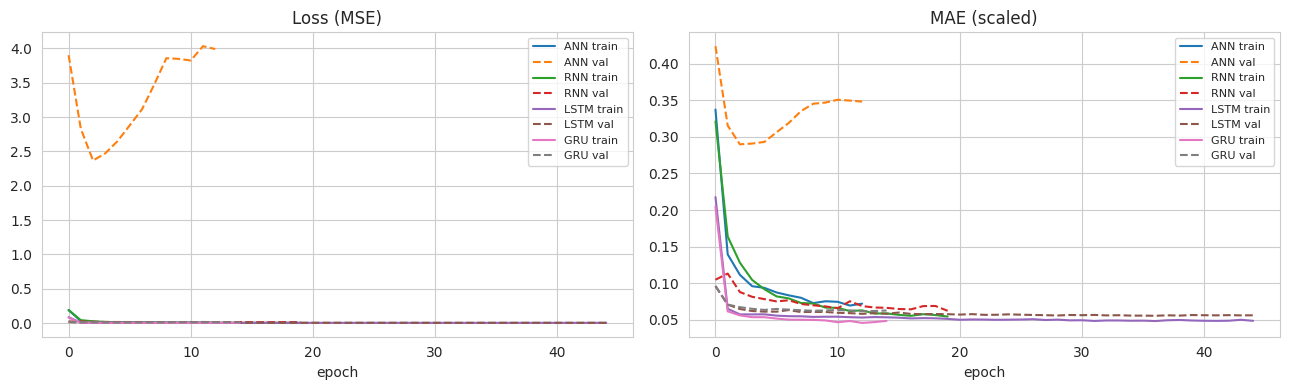

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, r in results.items():
    h = r['history']
    ax[0].plot(h['loss'],     label=f'{k.upper()} train')
    ax[0].plot(h['val_loss'], label=f'{k.upper()} val', linestyle='--')
    ax[1].plot(h['mae'],      label=f'{k.upper()} train')
    ax[1].plot(h['val_mae'],  label=f'{k.upper()} val', linestyle='--')
ax[0].set_title('Loss (MSE)'); ax[0].set_xlabel('epoch'); ax[0].legend(fontsize=8)
ax[1].set_title('MAE (scaled)'); ax[1].set_xlabel('epoch'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

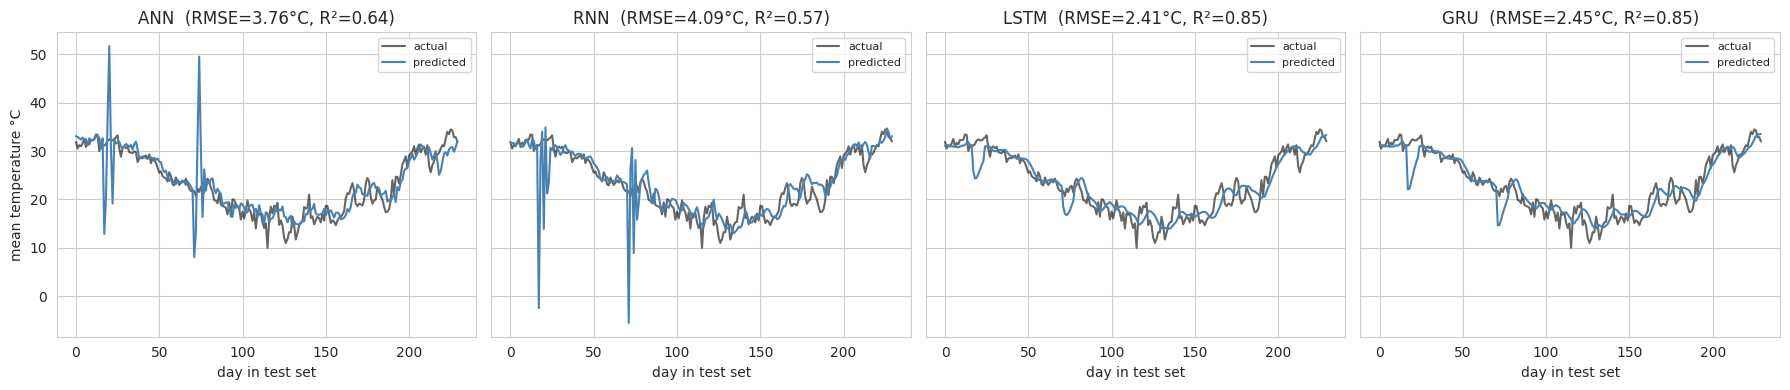

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, (k, r) in zip(axes, results.items()):
    ax.plot(r['y_true'], label='actual', color='black', alpha=0.6)
    ax.plot(r['y_pred'], label='predicted', color='steelblue')
    ax.set_title(f'{k.upper()}  (RMSE={r["rmse"]:.2f}°C, R²={r["r2"]:.2f})')
    ax.set_xlabel('day in test set'); ax.legend(fontsize=8)
axes[0].set_ylabel('mean temperature °C')
plt.tight_layout(); plt.show()

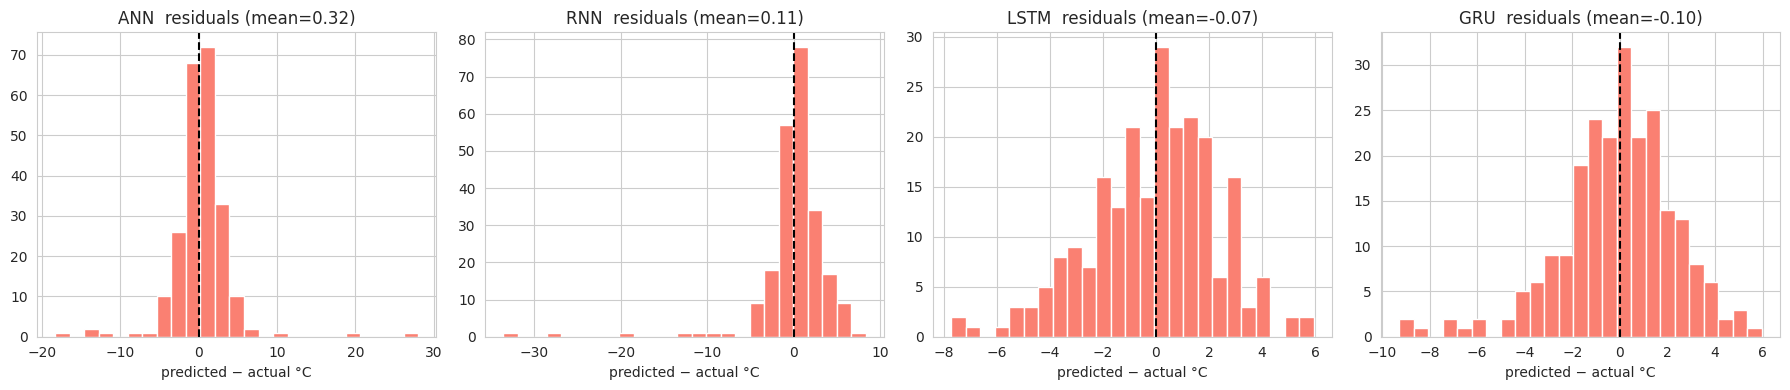

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (k, r) in zip(axes, results.items()):
    res = r['y_pred'] - r['y_true']
    ax.hist(res, bins=25, color='salmon', edgecolor='white')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(f'{k.upper()}  residuals (mean={res.mean():.2f})')
    ax.set_xlabel('predicted − actual °C')
plt.tight_layout(); plt.show()

## 5. Discussion

**Why all four models do well on Delhi data.**
Delhi temperature has a strong yearly seasonal cycle and a smooth day-to-day autocorrelation, so even a 7-day lookback contains almost all the information needed to predict the next day.  All four models converge to RMSE ≈ 1.5–2.5 °C and R² ≈ 0.9.

**Why ANN often surprises here.**
When the input length is short (only 7 timesteps) and the relationship between past and future is roughly *linear*, a simple feed-forward network operating on the flattened window is competitive with — and sometimes beats — recurrent models.  Recurrent networks shine when sequences are *long* and sequence order matters more than absolute position.

**Why LSTM / GRU still help.**
Both gated cells handle slightly noisy signals (humidity spikes, sensor glitches) better, and they generalise better when the test period contains weather regimes not present in training.  GRU usually trains the fastest of the three recurrent variants.

**Regularisation.**
* `Dropout(0.2)` between recurrent / dense layers.
* `EarlyStopping(patience=10, restore_best_weights=True)` — many models plateau within 30 epochs.
* `ReduceLROnPlateau` halves LR when val-loss stagnates.

**Why no ROC-AUC?**
ROC-AUC measures how well a *classifier* separates positive from negative examples by ranking probabilities.  This is a *regression* problem (continuous temperature output), so we instead report MAE, RMSE and R², plus a residual histogram and a predicted-vs-actual plot.  Task 3b (Seattle Weather Classification) covers ROC-AUC.